<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/tugas/praktikum/praktikum10/Maryam_Hasnaa'_Syamila_0110222067_PraktikumMandiri10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Praktikum Mandiri 10 - KNN**

- **Nama :** Maryam Hasnaa' Syamila
- **NIM  :** 0110222067

### **Latihan 1 - Klasifikasi Suhu (Panas/Dingin)**

#### **1. Import Library**

In [1]:
# Import library
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Optional: menangani imbalance (jika dataset lebih besar)
# from imblearn.over_sampling import SMOTE

# Menyimpan model
import joblib

# Set opsi tampilan
sns.set(style="whitegrid")

#### **2. Buat Dataset**

In [3]:
# 2) Membuat DataFrame manual sesuai soal
data = {
    "Temperature_C": [10, 25, 15, 20, 18, 20, 22, 24],
    "Wind_kmh":       [0,  0,  5,  3,  7,  10, 5,  6],
    "Perception":     ["Dingin", "Panas", "Dingin", "Panas",
                       "Dingin", "Dingin", "Panas", "Panas"]
}

df = pd.DataFrame(data)
df  # tampilkan tabel

,Temperature_C,Wind_kmh,Perception
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


#### **3. Info Dataset**

In [4]:
# Info dataset
print("Shape:", df.shape)
print("\nDistribusi label:\n", df['Perception'].value_counts())
print("\nDescriptive stats:\n", df.describe())

Shape: (8, 3)

Distribusi label:
 Perception
Dingin    4
Panas     4
Name: count, dtype: int64

Descriptive stats:
        Temperature_C   Wind_kmh
count       8.000000   8.000000
mean       19.250000   4.500000
std         4.920801   3.422614
min        10.000000   0.000000
25%        17.250000   2.250000
50%        20.000000   5.000000
75%        22.500000   6.250000
max        25.000000  10.000000


#### **4. Encoding label menjadi numerik**

In [5]:
# Encoding label
df['Label'] = df['Perception'].map({'Dingin': 0, 'Panas': 1})
df = df.drop(columns=['Perception'])  # hapus kolom teks
df

,Temperature_C,Wind_kmh,Label
0,10,0,0
1,25,0,1
2,15,5,0
3,20,3,1
4,18,7,0
5,20,10,0
6,22,5,1
7,24,6,1


#### **5. Visualisasi Temperatur vs Wind dengan Scatter Plot**

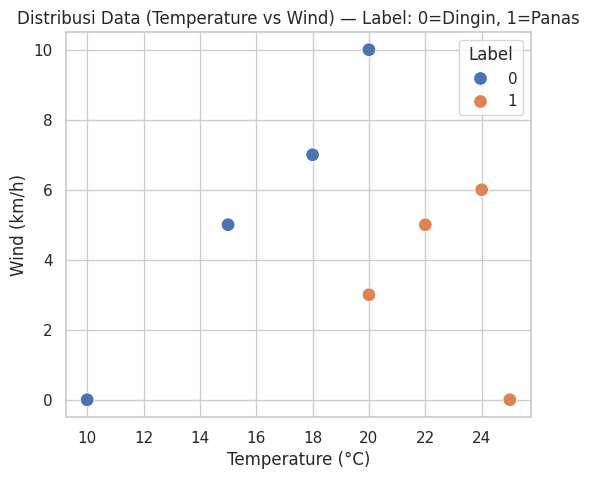

In [6]:
# Visualisasi
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='Temperature_C', y='Wind_kmh', hue='Label', s=100)
plt.title("Distribusi Data (Temperature vs Wind) — Label: 0=Dingin, 1=Panas")
plt.xlabel("Temperature (°C)")
plt.ylabel("Wind (km/h)")
plt.legend(title='Label')
plt.show()

#### **6. Pemisahan fitur (X) dan label (Y) & Split Data**

In [7]:
# Pisahkan fitur & label, split data
X = df[['Temperature_C', 'Wind_kmh']].values
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (6, 2) X_test: (2, 2)


#### **7. Normalisasi dengan StandardScaler**

In [8]:
# Scaling fitur dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# tampilkan hasil scaling (contoh)
print("X_train (scaled) contoh:\n", X_train_scaled[:3])

X_train (scaled) contoh:
 [[ 1.161895   -1.13898959]
 [-0.77459667  0.2847474 ]
 [ 0.19364917 -0.2847474 ]]


#### **8. Hyperparameter Tuning**

In [9]:
# GridSearch untuk hyperparameter KNN
param_grid = {
    'n_neighbors': list(range(1, 11)),  # K dari 1 sampai 10
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV score (train):", grid.best_score_)


Best params: {'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'}
Best CV score (train): 0.8333333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.66666667 0.66666667 0.83333333 0.66666667 0.66666667 0.66666667
 0.5        0.83333333        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan 0.5        0.5        0.66666667 0.5
 0.5        0.5        0.5        0.66666667 0.5               nan
 0.5               nan 0.5               nan 0.5               nan
 0.5               nan 0.5               nan]
  warnings.warn(


#### **9. Train & Evaluasi Model**

In [10]:
# Evaluasi model terbaik
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print("Accuracy (test):", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy (test): 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



#### **10. Cek Kestabilan (Cross Validation)**

In [11]:
# Cross-validation
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=3, scoring='accuracy')
print("CV scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean(), "std:", cv_scores.std())

CV scores: [1.  0.5 1. ]
CV mean accuracy: 0.8333333333333334 std: 0.23570226039551584


#### **11. Elbow Method (error rate vs K)**

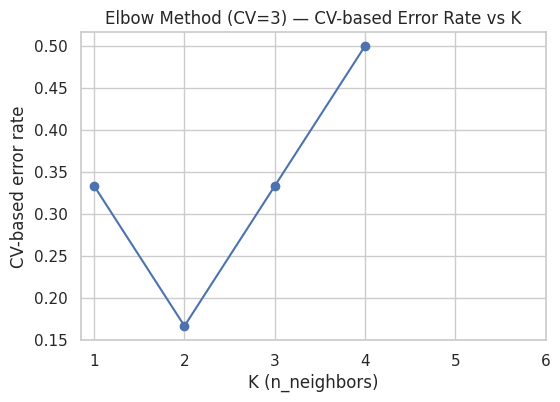

n_train: 6   cv: 3
CV-based error rates per K: [(1, np.float64(0.33333333333333337)), (2, np.float64(0.16666666666666663)), (3, np.float64(0.33333333333333337)), (4, np.float64(0.5)), (5, np.float64(nan)), (6, np.float64(nan))]


In [16]:
# Elbow method: hitung error rate per K
from sklearn.model_selection import cross_val_score

n_train = X_train_scaled.shape[0]            # jumlah sampel di training
max_k = min(10, n_train)                     # batasi K maksimum <= n_train (jangan lebih besar)
Ks = range(1, max_k + 1)

# Pilih cv yang masuk akal: pakai 3 jika ada cukup data, kalau tidak gunakan n_train (LOO-like)
cv = 3 if n_train >= 3 else n_train

cv_error_rates = []  # akan menyimpan nilai error (1 - mean_accuracy) untuk tiap K

for k in Ks:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    # cross_val_score mengembalikan array skor untuk tiap fold
    scores = cross_val_score(knn_k, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    mean_acc = scores.mean()
    cv_error_rates.append(1 - mean_acc)  # error rate = 1 - accuracy

# Plot hasil
plt.figure(figsize=(6,4))
plt.plot(list(Ks), cv_error_rates, marker='o')
plt.title(f'Elbow Method (CV={cv}) — CV-based Error Rate vs K')
plt.xlabel('K (n_neighbors)')
plt.ylabel('CV-based error rate')
plt.xticks(list(Ks))
plt.grid(True)
plt.show()

print("n_train:", n_train, "  cv:", cv)
print("CV-based error rates per K:", list(zip(list(Ks), cv_error_rates)))


#### **12. Retraining Model dengan K terbaik**

In [17]:
# Latih ulang model KNN dengan K terbaik hasil elbow
best_k = 2
final_knn = KNeighborsClassifier(n_neighbors=best_k)

# Latih model menggunakan data train
final_knn.fit(X_train_scaled, y_train)

# Evaluasi ulang di test set
y_pred_final = final_knn.predict(X_test_scaled)

print("Accuracy (test):", accuracy_score(y_test, y_pred_final))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

Accuracy (test): 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



#### **13. Simpan Model**

In [18]:
joblib.dump(final_knn, "knn_final_k2_model.joblib")
joblib.dump(scaler, "knn_scaler.joblib")

['knn_scaler.joblib']

#### **14. Prediksi kasus uji dari soal**

In [20]:
sample_T = 16
sample_W = 3

sample = np.array([[sample_T, sample_W]])
sample_scaled = scaler.transform(sample)
pred = final_knn.predict(sample_scaled)[0]

label_map = {0: "Dingin", 1: "Panas"}

print("=== Prediksi Persepsi Marry ===")
print(f"Temperatur input  : {sample_T}°C")
print(f"Kecepatan angin   : {sample_W} km/jam")
print(f"Hasil prediksi    : {label_map[pred]}")

=== Prediksi Persepsi Marry ===
Temperatur input  : 16°C
Kecepatan angin   : 3 km/jam
Hasil prediksi    : Dingin


### **Latihan 2 - Prediksi Kelulusan Mata Kuliah AI**

#### **1. Import Library**

In [21]:
# Import library
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# tampilkan agar output tabel rapi di notebook
pd.set_option('display.expand_frame_repr', False)


#### **2. Buat Dataset**

In [22]:
# Membuat DataFrame manual sesuai tabel pada soal
data = {
    "NIM": ["TI001","TI002","TI003","TI004","TI005","TI006","TI007","TI008","TI009","TI010"],
    "Actual": ["Lulus","Lulus","Lulus","Tidak Lulus","Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"],
    "Pred":   ["Lulus","Lulus","Lulus","Tidak Lulus","Tidak Lulus","Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]
}

df = pd.DataFrame(data)
df


,NIM,Actual,Pred
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Tidak Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


#### **3. Distribusi Dataset**

In [23]:
# Distribusi Actual dan Pred
print("Distribusi Actual:")
print(df['Actual'].value_counts())
print("\nDistribusi Prediksi:")
print(df['Pred'].value_counts())


Distribusi Actual:
Actual
Tidak Lulus    6
Lulus          4
Name: count, dtype: int64

Distribusi Prediksi:
Pred
Tidak Lulus    6
Lulus          4
Name: count, dtype: int64


#### **4. Encode Label menjadi numerik**

In [25]:
# Encoding label
label_map = {"Lulus": 1, "Tidak Lulus": 0}
df['Actual_bin'] = df['Actual'].map(label_map)
df['Pred_bin'] = df['Pred'].map(label_map)

df[['NIM','Actual','Pred','Actual_bin','Pred_bin']]


,NIM,Actual,Pred,Actual_bin,Pred_bin
0,TI001,Lulus,Lulus,1,1
1,TI002,Lulus,Lulus,1,1
2,TI003,Lulus,Lulus,1,1
3,TI004,Tidak Lulus,Tidak Lulus,0,0
4,TI005,Lulus,Tidak Lulus,1,0
5,TI006,Tidak Lulus,Lulus,0,1
6,TI007,Tidak Lulus,Tidak Lulus,0,0
7,TI008,Tidak Lulus,Tidak Lulus,0,0
8,TI009,Tidak Lulus,Tidak Lulus,0,0
9,TI010,Tidak Lulus,Tidak Lulus,0,0


#### **4. Hitung Confusion Matrix**

In [26]:
# Confusion matrix dengan label order [1,0] (1=Lulus, 0=Tidak Lulus)
labels = [1, 0]
cm = confusion_matrix(df['Actual_bin'], df['Pred_bin'], labels=labels)
cm_df = pd.DataFrame(cm, index=['Actual_Lulus(1)','Actual_TidakLulus(0)'], columns=['Pred_Lulus(1)','Pred_TidakLulus(0)'])
print("Confusion Matrix (baris=actual, kolom=prediksi):")
display(cm_df)


Confusion Matrix (baris=actual, kolom=prediksi):


,Pred_Lulus(1),Pred_TidakLulus(0)
Actual_Lulus(1),3,1
Actual_TidakLulus(0),1,5


#### **5. Ambil TP, FP, FN, TN**
- **TP (True Positive)** = Actual Lulus & Prediksi Lulus  
- **FP (False Positive)** = Actual Tidak Lulus & Prediksi Lulus  
- **FN (False Negative)** = Actual Lulus & Prediksi Tidak Lulus  
- **TN (True Negative)** = Actual Tidak Lulus & Prediksi Tidak Lulus


In [27]:
# Ekstrak TP, FP, FN, TN dari cm
TP = cm[0,0]
FN = cm[0,1]
FP = cm[1,0]
TN = cm[1,1]

print(f"TP (Actual Lulus & Prediksi Lulus)        : {TP}")
print(f"FN (Actual Lulus & Prediksi Tidak Lulus)  : {FN}")
print(f"FP (Actual Tidak Lulus & Prediksi Lulus) : {FP}")
print(f"TN (Actual Tidak Lulus & Prediksi Tidak Lulus): {TN}")

TP (Actual Lulus & Prediksi Lulus)        : 3
FN (Actual Lulus & Prediksi Tidak Lulus)  : 1
FP (Actual Tidak Lulus & Prediksi Lulus) : 1
TN (Actual Tidak Lulus & Prediksi Tidak Lulus): 5


#### **6. Hitung accuracy, precision, recall (dalam %)**
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)  
- **Precision** = TP / (TP + FP)  (untuk kelas positif = 'Lulus')  
- **Recall** = TP / (TP + FN)     (untuk kelas positif = 'Lulus')


In [28]:
# Perhitungan metrik (sklearn)
y_true = df['Actual_bin']
y_pred = df['Pred_bin']

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1)  # fokus pada kelas 'Lulus' sebagai positif
rec = recall_score(y_true, y_pred, pos_label=1)

# Perhitungan manual (untuk verifikasi)
total = TP + TN + FP + FN
acc_manual = (TP + TN) / total
prec_manual = TP / (TP + FP) if (TP + FP) > 0 else 0.0
rec_manual = TP / (TP + FN) if (TP + FN) > 0 else 0.0

# Tampilkan sebagai persen dengan 2 desimal
print("=== Hasil (sklearn) ===")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall   : {rec*100:.2f}%")

print("\n=== Hasil (manual verifikasi) ===")
print(f"Accuracy : {acc_manual*100:.2f}%")
print(f"Precision: {prec_manual*100:.2f}%")
print(f"Recall   : {rec_manual*100:.2f}%")


=== Hasil (sklearn) ===
Accuracy : 80.00%
Precision: 75.00%
Recall   : 75.00%

=== Hasil (manual verifikasi) ===
Accuracy : 80.00%
Precision: 75.00%
Recall   : 75.00%


#### **7. Classification Report**

In [29]:
# Classification report
print("Classification Report (per kelas):")
print(classification_report(y_true, y_pred, target_names=['Tidak Lulus','Lulus']))

Classification Report (per kelas):
              precision    recall  f1-score   support

 Tidak Lulus       0.83      0.83      0.83         6
       Lulus       0.75      0.75      0.75         4

    accuracy                           0.80        10
   macro avg       0.79      0.79      0.79        10
weighted avg       0.80      0.80      0.80        10



#### **8. Interpretasi singkat**
- Nilai TP/FP/FN/TN
- Accuracy, Precision, Recall dalam persen  
- Kesimpulan (interpretasi singkat dari metrik)


In [30]:
# Persiapan ringkasan interpretasi
print("Ringkasan singkat:")
print(f"- Total sampel : {total}")
print(f"- TP = {TP}, FP = {FP}, FN = {FN}, TN = {TN}")
print(f"- Accuracy = {acc*100:.2f}%")
print(f"- Precision (Lulus) = {prec*100:.2f}%")
print(f"- Recall    (Lulus) = {rec*100:.2f}%")

# Interpretasi singkat otomatis
if prec < 0.5:
    note_prec = "precision rendah → banyak prediksi 'Lulus' yang salah"
else:
    note_prec = "precision baik → sebagian besar prediksi 'Lulus' benar"

if rec < 0.5:
    note_rec = "recall rendah → model sering gagal menangkap actual 'Lulus'"
else:
    note_rec = "recall baik → model berhasil menangkap actual 'Lulus'"

print("\nInterpretasi:")
print(f"- {note_prec}.")
print(f"- {note_rec}.")


Ringkasan singkat:
- Total sampel : 10
- TP = 3, FP = 1, FN = 1, TN = 5
- Accuracy = 80.00%
- Precision (Lulus) = 75.00%
- Recall    (Lulus) = 75.00%

Interpretasi:
- precision baik → sebagian besar prediksi 'Lulus' benar.
- recall baik → model berhasil menangkap actual 'Lulus'.


### **Latihan 3 - Prediksi Cuaca menggunakan KNN**

#### **1. Import Library**

In [31]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

#### **2. Buat Dataset**

In [32]:
# Dataset
data = {
    "Temperature":[14.0,39.0,30.0,38.0,27.0,32.0,-2.0,3.0,3.0,28.0],
    "Humidity":[73,96,64,83,74,55,97,85,83,74],
    "Wind Speed":[9.5,8.5,7.0,1.5,17.0,3.5,8.0,6.0,6.0,8.5],
    "Precipitation":[82.0,71.0,16.0,82.0,66.0,26.0,86.0,96.0,66.0,107.0],
    "Cloud Cover":["partly cloudy","partly cloudy","clear","clear","overcast","overcast","overcast","partly cloudy","overcast","clear"],
    "Atmospheric Pressure":[1010.82,1011.43,1018.72,1026.25,990.67,1010.03,990.87,984.46,999.44,1012.13],
    "UV Index":[2,7,5,7,1,2,1,1,0,8],
    "Season":["Winter","Spring","Spring","Spring","Winter","Summer","Winter","Winter","Winter","Winter"],
    "Visibility":[3.5,10.0,5.5,1.0,2.5,5.0,4.0,3.5,1.0,7.5],
    "Location":["inland","inland","mountain","coastal","mountain","inland","inland","inland","mountain","coastal"],
    "Weather Type":["Rainy","Cloudy","Sunny","Sunny","Rainy","Cloudy","Snowy","Snowy","Snowy","Sunny"]
}

df = pd.DataFrame(data)

# Mapping untuk label numerik
weather_map = {"Sunny":0,"Cloudy":1,"Rainy":2,"Snowy":3}
df["WeatherLabel"] = df["Weather Type"].map(weather_map)

df

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility,Location,Weather Type,WeatherLabel
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,2
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,1
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,2
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy,1
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy,3
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy,3
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy,3
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny,0


#### **3. Info Dataset**

In [33]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

Shape: (10, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           10 non-null     float64
 1   Humidity              10 non-null     int64  
 2   Wind Speed            10 non-null     float64
 3   Precipitation         10 non-null     float64
 4   Cloud Cover           10 non-null     object 
 5   Atmospheric Pressure  10 non-null     float64
 6   UV Index              10 non-null     int64  
 7   Season                10 non-null     object 
 8   Visibility            10 non-null     float64
 9   Location              10 non-null     object 
 10  Weather Type          10 non-null     object 
 11  WeatherLabel          10 non-null     int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 1.1+ KB
None

Missing values:
Temperature             0
Humidity                0
Wind Speed              0

#### **4. Encoding Kolom Kategorikal**

In [34]:
df_encoded = df.copy()

# Encoding kategori → angka
df_encoded["CloudCoverNum"] = df_encoded["Cloud Cover"].map({
    "clear":0, "partly cloudy":1, "overcast":2
})

df_encoded["SeasonNum"] = df_encoded["Season"].map({
    "Winter":0, "Spring":1, "Summer":2, "Autumn":3
})

df_encoded["LocationNum"] = df_encoded["Location"].map({
    "inland":0, "coastal":1, "mountain":2
})

df_encoded.head()

,Temperature,Humidity,Wind Speed,Precipitation,Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility,Location,Weather Type,WeatherLabel,CloudCoverNum,SeasonNum,LocationNum
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,2,1,0,0
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,1,1,1,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0,0,1,2
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0,0,1,1
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,2,2,0,2


#### **5. Pilih Fitur, Split Data, Scaling**

In [36]:
# Pilih fitur
features = [
    "Temperature","Humidity","Wind Speed","Precipitation",
    "Atmospheric Pressure","UV Index","Visibility",
    "CloudCoverNum","SeasonNum","LocationNum"
]

X = df_encoded[features]
y = df_encoded["WeatherLabel"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (5, 10) Test: (5, 10)


#### **6. Menyiapkan X_res dan y_res**

In [37]:
# Dataset kecil dan relatif seimbang → TIDAK pakai SMOTE
# Maka X_res dan y_res = data training yang sudah di-scale

X_res = X_train_scaled
y_res = y_train

print("Jumlah data train:", X_res.shape)
print("Distribusi label train:")
print(y_res.value_counts())

Jumlah data train: (5, 10)
Distribusi label train:
WeatherLabel
3    2
0    1
2    1
1    1
Name: count, dtype: int64


#### **7. Hyperparameter Tuning**

In [39]:
# Parameter grid untuk mencari kombinasi terbaik
param_grid = {
    "n_neighbors": list(range(1, 11)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn = KNeighborsClassifier()

# GridSearch dengan 3-fold cross-validation
grid = GridSearchCV(knn, param_grid, cv=2, n_jobs=-1)
grid.fit(X_res, y_res)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(


Best Params: {'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV Score: 0.41666666666666663


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.41666667 0.41666667 0.         0.41666667        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan 0.41666667 0.41666667 0.         0.41666667
 0.16666667        nan 0.41666667        nan 0.41666667        nan
 0.41666667        nan 0.41666667        nan 0.41666667        nan
 0.41666667        nan 0.41666667        nan]
  warnings.warn(


#### **8. Training & Evaluasi Model**

In [40]:
# Ambil model terbaik
best_knn = grid.best_estimator_

# Train model menggunakan data training (X_res)
best_knn.fit(X_res, y_res)

# Prediksi pada data test (belum di-resample)
y_pred = best_knn.predict(X_test_scaled)

print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy on Test Set: 0.4

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           2       0.33      1.00      0.50         1
           3       1.00      1.00      1.00         1

    accuracy                           0.40         5
   macro avg       0.33      0.50      0.38         5
weighted avg       0.27      0.40      0.30         5

Confusion Matrix:
[[0 1 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 0 1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### **9. Elbow Method**

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 144, in __call__
    score = scorer(estimator, *args, **routed_params.get(name).score)
            ^^^^^^^^

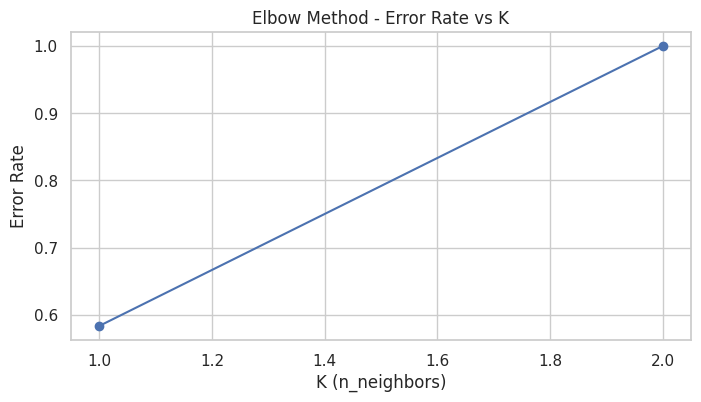

In [43]:
error_rate = []
k_range = range(1, 16)

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    # cv=2 karena dataset kecil
    scores = cross_val_score(model, X_res, y_res, cv=2)
    error_rate.append(1 - scores.mean())

plt.figure(figsize=(8,4))
plt.plot(list(k_range), error_rate, marker='o')
plt.title("Elbow Method - Error Rate vs K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

#### **9. PCA Visualisasi (2D)**

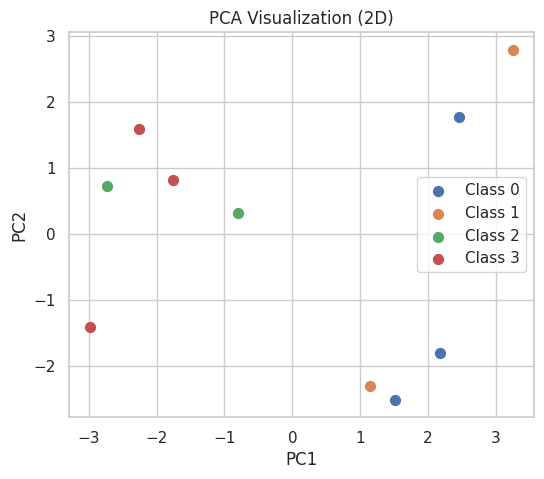

In [44]:
pca = PCA(n_components=2, random_state=42)

# Gabungkan X_res dan X_test_scaled untuk visualisasi
X_pca = pca.fit_transform(
    np.vstack([X_res, X_test_scaled])
)
y_pca = np.concatenate([y_res, y_test.values])

plt.figure(figsize=(6,5))
for label in np.unique(y_pca):
    idx = np.where(y_pca == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Class {label}", s=50)

plt.title("PCA Visualization (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


#### **10. Simpan Model**

In [45]:
import joblib
from google.colab import drive
drive.mount('/content/drive')
import os

save_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum10/models"
os.makedirs(save_path, exist_ok=True)
print("Folder siap digunakan:", save_path)

# Simpan model terbaik ke file
model_save_file = os.path.join(save_path, "knn_weather_model.pkl")
joblib.dump(best_knn, model_save_file)
print("Model berhasil disimpan ke:", model_save_file)

Mounted at /content/drive
Folder siap digunakan: /content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum10/models
Model berhasil disimpan ke: /content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum10/models/knn_weather_model.pkl


#### **11. Load & Uji Coba Model**

In [49]:
# data uji
new_data = [[
    25,    # Temperature
    70,    # Humidity
    8,     # Wind Speed
    60,    # Precipitation
    1005,  # Atmospheric Pressure
    5,     # UV Index
    5,     # Visibility
    1,     # CloudCoverNum (partly cloudy)
    0,     # SeasonNum (Winter)
    0      # LocationNum (inland)
]]

# print soal
print("=== DATA INPUT UNTUK UJI COBA ===")
print(f"Temperature          : {new_data[0][0]}")
print(f"Humidity             : {new_data[0][1]}")
print(f"Wind Speed           : {new_data[0][2]}")
print(f"Precipitation        : {new_data[0][3]}")
print(f"Atmospheric Pressure : {new_data[0][4]}")
print(f"UV Index             : {new_data[0][5]}")
print(f"Visibility           : {new_data[0][6]}")
print(f"CloudCoverNum        : {new_data[0][7]}")
print(f"SeasonNum            : {new_data[0][8]}")
print(f"LocationNum          : {new_data[0][9]}")
print()

# scaling
new_data_scaled = scaler.transform(new_data)

print("=== DATA SETELAH SCALING ===")
print(new_data_scaled)
print()

# load model
loaded_model = joblib.load("/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum10/models/knn_weather_model.pkl")

# prediksi
pred_label = loaded_model.predict(new_data_scaled)[0]
inverse_map = {0:"Sunny", 1:"Cloudy", 2:"Rainy", 3:"Snowy"}

print("=== HASIL PREDIKSI CUACA ===")
print(f"Label Prediksi : {pred_label}")
print(f"Weather Type   : {inverse_map[pred_label]}")

=== DATA INPUT UNTUK UJI COBA ===
Temperature          : 25
Humidity             : 70
Wind Speed           : 8
Precipitation        : 60
Atmospheric Pressure : 1005
UV Index             : 5
Visibility           : 5
CloudCoverNum        : 1
SeasonNum            : 0
LocationNum          : 0

=== DATA SETELAH SCALING ===
[[ 0.48030907 -0.51719787  1.00206399 -0.43070922 -0.08676805  1.07588766
   1.40266877 -0.26726124 -0.75       -0.75      ]]

=== HASIL PREDIKSI CUACA ===
Label Prediksi : 2
Weather Type   : Rainy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
